# Exercise 10 - Bagging, Boosting & Anomaly Detection

Back in Tutorial 6 we built a single **decision tree**. A single tree is easy to read but tends to either underfit (too shallow) or overfit (too deep, memorizing noise). The standard fix is to stop relying on one tree and instead combine **many** trees into an **ensemble**. There are two very different ways to do that:

* **Bagging** - train many trees independently, each on a random resample of the data, and average their votes. **Random Forest** is the classic example.
* **Boosting** - train trees one after another, each one focused on fixing the mistakes of the trees before it. **XGBoost** is one of the most widely used implementations.

Both are still **supervised**: they need a labeled target `y` to learn from. Tutorials 8 and 9 went the other way and looked at **unsupervised** methods (K-means, PCA) that never see a label at all. This tutorial revisits that unsupervised idea, but for a different purpose - not finding clusters or reducing dimensions, but flagging points that don't look like the rest of the data:

* **Isolation Forest** - another tree-based ensemble, but built to isolate rare, unusual points rather than to classify.
* **Local Outlier Factor (LOF)** - flags a point as unusual if it sits in a much sparser neighborhood than its neighbors do.

We'll use all four algorithms on the same problem: spotting **credit card fraud** in the [Kaggle "Credit Card Fraud Detection" dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data). Fraud detection is a great setting to compare them, because it is a genuinely hard, extremely **imbalanced** classification problem, and it lets us ask a question that matters far beyond this dataset: when the thing you're looking for is rare, how do you even train and evaluate a model, and does it matter whether the model ever gets to see a labeled example of it?

In [1]:
import time

import numpy as np
import pandas as pd

import plotnine as pln
import warnings
from plotnine.exceptions import PlotnineWarning
warnings.filterwarnings("ignore", category=PlotnineWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero encountered in log10")

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    precision_recall_curve, auc,
)
import xgboost as xgb

RNG = 42

## The data

The dataset holds transactions made by European cardholders over two days in September 2013. For confidentiality reasons the original transaction features were transformed with PCA, so most columns are just called `V1`...`V28` - we don't know what they mean, only that they summarize the transaction. Two columns were left untransformed: `Time` (seconds elapsed since the first transaction in the dataset) and `Amount` (the transaction amount). `Class` is the label: `1` for fraud, `0` for a legitimate transaction.

In [2]:
df = pd.read_csv('data/creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
class_counts = df['Class'].value_counts()
fraud_rate = df['Class'].mean()

print(class_counts)
print(f"fraud rate: {fraud_rate:.4%}")

Class
0    284315
1       492
Name: count, dtype: int64
fraud rate: 0.1727%


Out of 284,807 transactions, only 492 are fraud - about **0.17%**. This kind of extreme skew is typical of fraud, disease screening, and rare-failure detection: the class we actually care about is a tiny minority.

It also means **accuracy is a useless metric here**. A "model" that never predicts fraud at all - just outputs `0` for every single transaction - would already be right 99.83% of the time. It would also be worthless, since it catches zero fraud. So for the rest of this tutorial we'll judge every model with **precision** (of the transactions we flagged, how many were really fraud?), **recall** (of the real fraud cases, how many did we catch?) and **F1** (their harmonic mean), read off a **confusion matrix** - not accuracy.

The imbalance is hard to even see on a plain bar chart, so we'll use a log scale and label the counts directly:

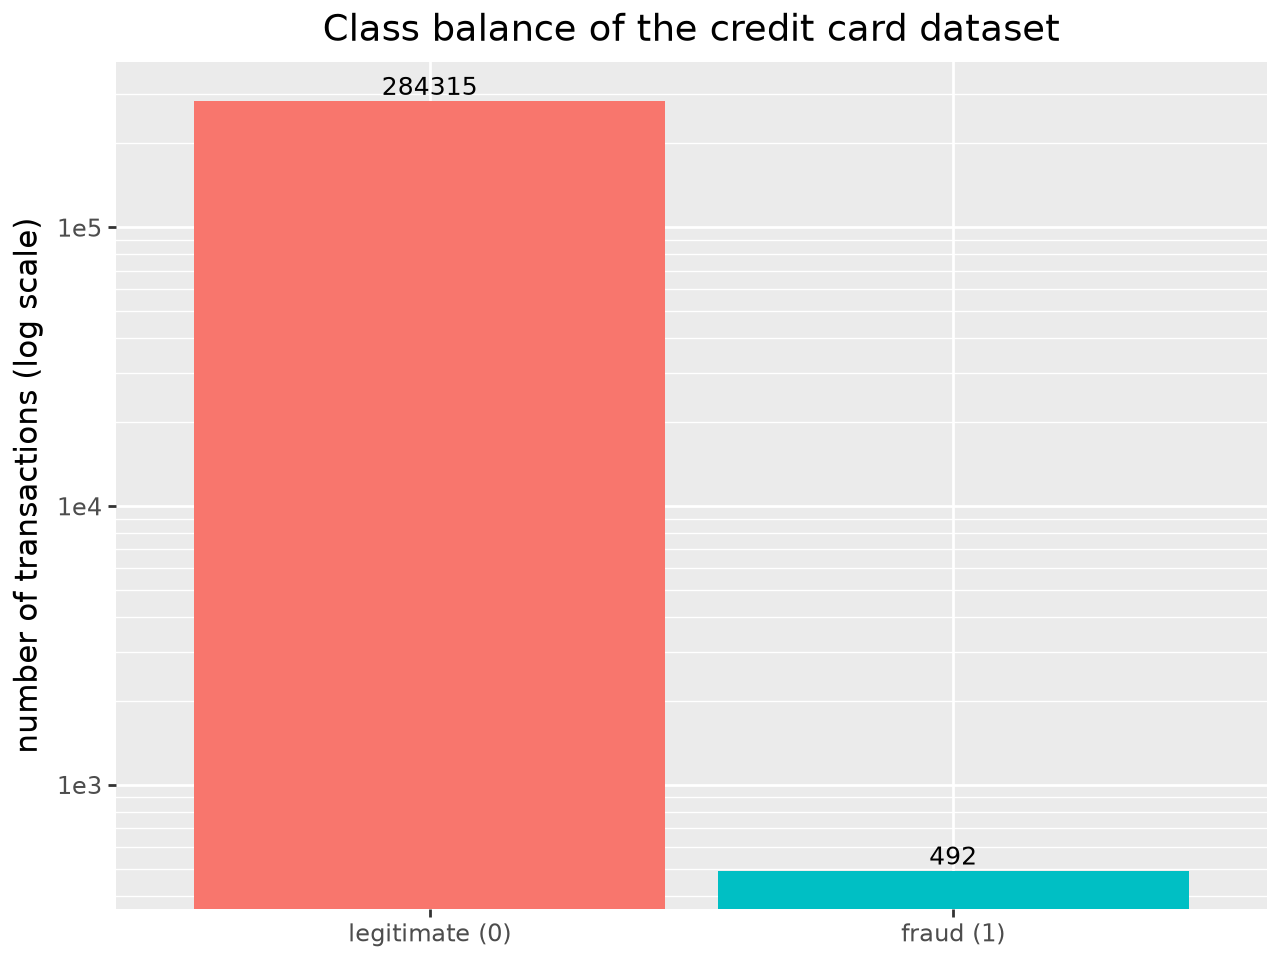

In [4]:
(
    pln.ggplot(df, pln.aes(x='factor(Class)', fill='factor(Class)'))
    + pln.geom_bar(show_legend=False)
    + pln.geom_text(pln.aes(label=pln.after_stat('count')), stat='count', va='bottom', size=9)
    + pln.scale_y_log10()
    + pln.scale_x_discrete(labels=['legitimate (0)', 'fraud (1)'])
    + pln.labs(x='', y='number of transactions (log scale)', title='Class balance of the credit card dataset')
)

    ## Sampling: why we can't just fit models on the raw data

There's a second, more practical problem: 284,807 rows is large enough that some of what we're about to do - especially **Local Outlier Factor**, which has to compute distances to nearby points for every transaction - gets noticeably slow to fit and refit interactively, which matters in a live class where we want to try things and see the result right away.

The obvious fix is to work with a smaller sample. But *how* we sample matters a lot, and it matters **differently** for our two families of algorithms:

* **Random Forest and XGBoost are supervised** - they learn directly from the `Class` label. If we sample randomly from the raw data, a sample of a few thousand rows would contain only a handful of fraud cases (at 0.17%, a 5,000-row sample has about 8-9 frauds on average) - nowhere near enough for a tree to learn what fraud looks like. The standard fix is to **undersample the majority class**, building a training set where fraud is no longer vanishingly rare. This is what people usually mean by a "balanced sample."
* **Isolation Forest and LOF are unsupervised** - they never look at `Class` while fitting. Their entire premise is that normal behavior is the overwhelming majority and anomalies are both rare *and* different. Hand them a 50/50 balanced sample and that premise is gone: with half the "training" data being fraud, fraud stops looking rare or unusual, and there's nothing left for either algorithm to isolate. So we do the **opposite** for these two: fit them on a sample of confirmed-**normal** transactions only, which is also a realistic setup - you often build an anomaly detector from historical data before you have any confirmed fraud labels at all.

We'll therefore carve out several disjoint slices of the data:

* `fraud_train` / `fraud_test` - the 492 known frauds, split so some are used for training and the rest only ever appear in the test set.
* a small **balanced sample** (equal parts fraud and legitimate) to see what plain undersampling does for Random Forest and XGBoost.
* a **moderate, still-imbalanced sample** (a few hundred fraud cases among many more legitimate ones) to see whether we can do better while keeping training fast.
* a **normal-only sample** to fit Isolation Forest and LOF on.
* one shared, **realistically-imbalanced test set** (roughly matching the true ~0.17%-ish fraud rate) that every single model is evaluated against, so the comparison at the end is fair and reflects what would actually happen in production.

In [5]:
fraud = df[df['Class'] == 1]
nonfraud = df[df['Class'] == 0]

# 492 known frauds: 60% for training, 40% held out purely for testing
fraud_train = fraud.sample(n=295, random_state=RNG)
fraud_test = fraud.drop(fraud_train.index)

nonfraud_shuffled = nonfraud.sample(frac=1, random_state=RNG)
nonfraud_balanced       = nonfraud_shuffled.iloc[:295]            # for the balanced sample
nonfraud_anomaly_train  = nonfraud_shuffled.iloc[295:5295]        # normal-only, for IsolationForest/LOF
nonfraud_test           = nonfraud_shuffled.iloc[5295:25295]      # for the shared test set
nonfraud_remaining_pool = nonfraud_shuffled.iloc[25295:]          # untouched, for the moderate sample

nonfraud_moderate = nonfraud_remaining_pool.sample(n=20_000, random_state=RNG)

features = [c for c in df.columns if c not in ('Class', 'Time')]

balanced_train = pd.concat([fraud_train, nonfraud_balanced]).sample(frac=1, random_state=RNG)
moderate_train = pd.concat([fraud_train, nonfraud_moderate]).sample(frac=1, random_state=RNG)
anomaly_train  = nonfraud_anomaly_train.sample(frac=1, random_state=RNG)
test_set       = pd.concat([fraud_test, nonfraud_test]).sample(frac=1, random_state=RNG)

X_bal_train, y_bal_train = balanced_train[features], balanced_train['Class']
X_mod_train, y_mod_train = moderate_train[features], moderate_train['Class']
X_anomaly_train = anomaly_train[features]
X_test, y_test = test_set[features], test_set['Class']

for name, d in [('balanced_train', balanced_train), ('moderate_train', moderate_train),
                ('anomaly_train (normal only)', anomaly_train), ('test_set', test_set)]:
    rate = d['Class'].mean() if 'Class' in d else 0.0
    print(f"{name:30s} rows={len(d):>7,}  fraud rate={rate:.3%}")

balanced_train                 rows=    590  fraud rate=50.000%
moderate_train                 rows= 20,295  fraud rate=1.454%
anomaly_train (normal only)    rows=  5,000  fraud rate=0.000%
test_set                       rows= 20,197  fraud rate=0.975%


We dropped `Time` from the feature set - it's just seconds elapsed since the first transaction, not a property of the transaction itself, and keeping the feature set simple also helps the distance-based LOF model later on.

## Bagging: Random Forest

A single decision tree fit to one training set is unstable: change the data slightly and you can get a very different tree. **Bagging** tackles this by:

1. Drawing many **bootstrap samples** from the training data (random samples of the same size, drawn *with replacement*, so each one leaves out roughly a third of the rows and duplicates others).
2. Fitting an independent tree to each bootstrap sample (a **Random Forest** also randomizes which features each split is allowed to consider, decorrelating the trees further).
3. Combining all the trees' predictions by majority vote.

Because the trees are trained independently, this mainly reduces **variance**: individual trees may overfit their own bootstrap sample in different, uncorrelated ways, and averaging cancels a lot of that out. Let's fit one on our small balanced sample and evaluate it on the realistic test set:

In [6]:
t0 = time.time()
rf_balanced = RandomForestClassifier(n_estimators=200, random_state=RNG, n_jobs=-1)
rf_balanced.fit(X_bal_train, y_bal_train)
fit_time = time.time() - t0

y_pred = rf_balanced.predict(X_test)
print(f"fit time: {fit_time:.2f}s")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['legit', 'fraud'], zero_division=0))

fit time: 0.36s
[[19465   535]
 [   21   176]]
              precision    recall  f1-score   support

       legit       1.00      0.97      0.99     20000
       fraud       0.25      0.89      0.39       197

    accuracy                           0.97     20197
   macro avg       0.62      0.93      0.69     20197
weighted avg       0.99      0.97      0.98     20197



It trains almost instantly (barely 600 rows) and catches the large majority of fraud cases - but look at the precision: most of what it flags as fraud is actually legitimate. We'll come back to why in a moment.

## Boosting: XGBoost

**Boosting** also combines many trees, but sequentially rather than independently:

1. Fit a first (usually very shallow, "weak") tree.
2. Look at where the current ensemble is wrong, and fit the *next* tree specifically to correct those mistakes (XGBoost does this by fitting each new tree to the **gradient** of the loss function with respect to the current predictions).
3. Add the new tree to the ensemble with some learning-rate weight, and repeat.

Because each tree is deliberately chasing the previous ensemble's errors, boosting mainly reduces **bias** - it can drive training error very low. The flip side is that it's more sensitive to noisy or mislabeled data than bagging, since a mislabeled point just looks like a "mistake to fix" and boosting will happily keep building trees that chase it.

Let's fit XGBoost the same way, on the same balanced sample:

In [7]:
t0 = time.time()
xgb_balanced = xgb.XGBClassifier(n_estimators=200, random_state=RNG, eval_metric='logloss')
xgb_balanced.fit(X_bal_train, y_bal_train)
fit_time = time.time() - t0

y_pred = xgb_balanced.predict(X_test)
print(f"fit time: {fit_time:.2f}s")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['legit', 'fraud'], zero_division=0))

fit time: 0.16s


[[19238   762]
 [   16   181]]
              precision    recall  f1-score   support

       legit       1.00      0.96      0.98     20000
       fraud       0.19      0.92      0.32       197

    accuracy                           0.96     20197
   macro avg       0.60      0.94      0.65     20197
weighted avg       0.99      0.96      0.97     20197



Same story as Random Forest: high recall, weak precision. **Bagging vs. boosting**, in short:

| | Bagging (Random Forest) | Boosting (XGBoost) |
|---|---|---|
| Trees trained | independently, in parallel | sequentially, each fixing the last |
| Mainly reduces | variance (overfitting) | bias (underfitting) |
| Sensitivity to noisy labels | lower - noise gets averaged out | higher - it will keep chasing mislabeled points |
| Typical behavior | robust, hard to overfit by adding more trees | often more accurate, but needs care (learning rate, early stopping) to avoid overfitting |

## Balanced sampling: powerful, but it comes at a cost

Both models above catch ~89-92% of the fraud cases, which sounds great - but look at the false-positive counts: they flag hundreds of legitimate transactions as fraud for every batch of real fraud they find, which is why precision is so low (0.19-0.25). This is **not a coincidence, it's a direct consequence of how we sampled**.

The balanced training set told both models "fraud makes up 50% of transactions." Every probability and every decision boundary they learned is calibrated to that assumption. But the real world (and our test set) looks nothing like that - fraud is under 1% there - so both models end up **wildly over-predicting fraud** once we point them at realistic data. This is exactly why balanced sampling matters, and exactly why you have to be careful with it: undersampling the majority class is often the only practical way to get a model to pay attention to a rare class at all (with the raw 0.17% rate, both models would rarely even see a fraud example during training), but it distorts the class prior the model implicitly learns, and that distortion shows up directly in precision once you evaluate against real-world proportions.

There's a middle ground: instead of literally throwing away majority-class rows, keep a larger, still-imbalanced sample (more information for the model, and still fast to train) and instead correct for the imbalance directly in the *loss function*, via `class_weight='balanced'` (Random Forest) or `scale_pos_weight` (XGBoost) - upweighting mistakes on the minority class instead of relying on rebalancing the class ratio itself. Let's compare:

In [8]:
nonfraud_weight = (y_mod_train == 0).sum() / (y_mod_train == 1).sum()
print(f"legit:fraud ratio in moderate_train = {nonfraud_weight:.1f} : 1")

t0 = time.time()
rf_weighted = RandomForestClassifier(
    n_estimators=200, random_state=RNG, n_jobs=-1, class_weight='balanced'
)
rf_weighted.fit(X_mod_train, y_mod_train)
rf_fit_time = time.time() - t0

t0 = time.time()
xgb_weighted = xgb.XGBClassifier(
    n_estimators=200, random_state=RNG, eval_metric='logloss', scale_pos_weight=nonfraud_weight
)
xgb_weighted.fit(X_mod_train, y_mod_train)
xgb_fit_time = time.time() - t0

def summarize(name, y_true, y_pred, fit_time):
    return {
        'model': name,
        'fit_time_s': round(fit_time, 2),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }

supervised_results = [
    summarize('Random Forest (balanced sample)', y_test, rf_balanced.predict(X_test), fit_time=0.0),
    summarize('XGBoost (balanced sample)', y_test, xgb_balanced.predict(X_test), fit_time=0.0),
    summarize('Random Forest (moderate sample + class_weight)', y_test, rf_weighted.predict(X_test), rf_fit_time),
    summarize('XGBoost (moderate sample + scale_pos_weight)', y_test, xgb_weighted.predict(X_test), xgb_fit_time),
]
pd.DataFrame(supervised_results)

legit:fraud ratio in moderate_train = 67.8 : 1


,model,fit_time_s,precision,recall,f1
0,Random Forest (balanced sample),0.00,0.247539,0.893401,0.387665
1,XGBoost (balanced sample),0.00,0.191941,0.918782,0.317544
2,Random Forest (moderate sample + class_weight),1.68,0.947368,0.822335,0.880435
3,XGBoost (moderate sample + scale_pos_weight),0.43,0.942529,0.832487,0.884097


Keeping ~20,000 (still mostly legitimate) rows and weighting the loss instead of undersampling gets noticeably better precision *and* still-strong recall, and it still trains in a couple of seconds. The lesson isn't "never undersample" - a tiny balanced sample is still the fastest way to get a first model working at all, which matters when you're iterating live in class - it's that undersampling to strict 50/50 is one point on a spectrum, and keeping more of the majority class while reweighting the loss is often the better trade-off once training time allows it. We'll carry the weighted versions of Random Forest and XGBoost forward as "our" bagging and boosting models for the final comparison.

## Unsupervised anomaly detection: Isolation Forest & Local Outlier Factor

Random Forest and XGBoost both needed labeled fraud examples to learn from. Isolation Forest and LOF need none - they only ever look at the feature columns, never at `Class`. That makes them useful in situations supervised models can't handle at all: brand-new fraud patterns nobody has labeled yet, or systems where confirmed fraud labels only arrive weeks later (e.g. after a chargeback). The cost is that, with no labels to learn from, they have to fall back on a much simpler assumption: **normal points are the vast majority, and anomalies are both rare and different from the crowd.**

That's exactly why we fit both of them on `anomaly_train` - 5,000 **confirmed-legitimate** transactions, and nothing else. Handing them our balanced sample (50% fraud) would directly contradict the "anomalies are rare" assumption both algorithms are built on.

### Isolation Forest

Isolation Forest builds an ensemble of random trees, but with a different splitting rule than a normal decision tree: at each node, it picks a random feature and a random split point between that feature's min and max, with no regard for any label. Keep splitting randomly and every point eventually ends up alone in its own leaf - the question is *how many splits it took to isolate it*.

Points that are unusual (far from the bulk of the data, or with feature combinations nobody else has) tend to get isolated in just a few random splits, because there's a lot of "empty space" around them to split into. Ordinary points, packed in among many similar neighbors, take many more splits to separate out. So **short average path length across the forest = likely anomaly**. The `contamination` parameter tells the model roughly what fraction of points to expect to be anomalies, which sets the threshold on that path-length score.

In [9]:
contamination = 0.01  # our rough prior: we expect somewhere around 1% of transactions to be fraud

t0 = time.time()
iso_forest = IsolationForest(n_estimators=200, contamination=contamination, random_state=RNG, n_jobs=-1)
iso_forest.fit(X_anomaly_train)
fit_time = time.time() - t0

# IsolationForest.predict returns 1 for "normal" and -1 for "anomaly" - convert to the same 0/1 labels as Class
y_pred_iso = (iso_forest.predict(X_test) == -1).astype(int)

print(f"fit time: {fit_time:.2f}s")
print(confusion_matrix(y_test, y_pred_iso))
print(classification_report(y_test, y_pred_iso, target_names=['legit', 'fraud'], zero_division=0))

fit time: 0.36s
[[19836   164]
 [  100    97]]
              precision    recall  f1-score   support

       legit       0.99      0.99      0.99     20000
       fraud       0.37      0.49      0.42       197

    accuracy                           0.99     20197
   macro avg       0.68      0.74      0.71     20197
weighted avg       0.99      0.99      0.99     20197



### Local Outlier Factor

LOF takes a different, more local view. For every point it looks at its `k` nearest neighbors and compares two things: how spread out that point is from its neighbors, versus how spread out those neighbors are from *their* neighbors. A point sitting in a much sparser neighborhood than the neighborhood its own neighbors enjoy gets a high LOF score - it's **locally** unusual, even if it wouldn't stand out globally.

That locality is LOF's main advantage over Isolation Forest: it can catch anomalies that are only unusual relative to their immediate surroundings, in data where "normal" density varies from region to region. The cost is that it's explicitly **distance-based**, so (a) it needs every feature on a comparable scale, unlike our tree-based models which don't care about scale at all, and (b) it gets more expensive as the reference set grows, since every prediction requires a nearest-neighbor search. We set `novelty=True` so we can fit LOF on `anomaly_train` and then score new, unseen transactions against it - the standard way to use LOF outside of "score exactly the data I fit on":

In [10]:
scaler = StandardScaler().fit(X_anomaly_train)
X_anomaly_train_scaled = scaler.transform(X_anomaly_train)
X_test_scaled = scaler.transform(X_test)

t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=contamination)
lof.fit(X_anomaly_train_scaled)
fit_time = time.time() - t0

y_pred_lof = (lof.predict(X_test_scaled) == -1).astype(int)

print(f"fit time: {fit_time:.2f}s")
print(confusion_matrix(y_test, y_pred_lof))
print(classification_report(y_test, y_pred_lof, target_names=['legit', 'fraud'], zero_division=0))

fit time: 1.50s
[[19811   189]
 [   37   160]]
              precision    recall  f1-score   support

       legit       1.00      0.99      0.99     20000
       fraud       0.46      0.81      0.59       197

    accuracy                           0.99     20197
   macro avg       0.73      0.90      0.79     20197
weighted avg       0.99      0.99      0.99     20197



## Comparing all four

Both anomaly detectors catch a real chunk of the fraud - without ever seeing a single labeled fraud example during training - but noticeably less than our weighted supervised models, and with more false alarms per fraud case caught. That's a fair trade in exchange for needing zero labels.

The `contamination` threshold above is just one operating point though. Since all four models can produce a continuous **anomaly/fraud score** (not just a 0/1 call), we can compare them more completely with a **precision-recall curve**: for every possible score threshold, what precision and recall would we get? This also happens to be the right tool for the job on imbalanced data specifically, since (unlike the more common ROC curve) it isn't inflated by the huge number of easy true negatives.

In [11]:
scores = {
    'Random Forest': rf_weighted.predict_proba(X_test)[:, 1],
    'XGBoost': xgb_weighted.predict_proba(X_test)[:, 1],
    'Isolation Forest': -iso_forest.score_samples(X_test),
    'LOF': -lof.score_samples(X_test_scaled),
}

final_results = []
curve_rows = []
for name, y_score in scores.items():
    y_pred = (
        rf_weighted.predict(X_test) if name == 'Random Forest' else
        xgb_weighted.predict(X_test) if name == 'XGBoost' else
        y_pred_iso if name == 'Isolation Forest' else
        y_pred_lof
    )
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = auc(recall, precision)
    final_results.append({
        'model': name,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'pr_auc': pr_auc,
    })
    curve_rows.append(pd.DataFrame({'model': name, 'precision': precision, 'recall': recall}))

final_df = pd.DataFrame(final_results)
curves_df = pd.concat(curve_rows, ignore_index=True)
final_df

,model,precision,recall,f1,pr_auc
0,Random Forest,0.947368,0.822335,0.880435,0.885607
1,XGBoost,0.942529,0.832487,0.884097,0.885122
2,Isolation Forest,0.371648,0.492386,0.423581,0.446452
3,LOF,0.458453,0.812183,0.586081,0.741197


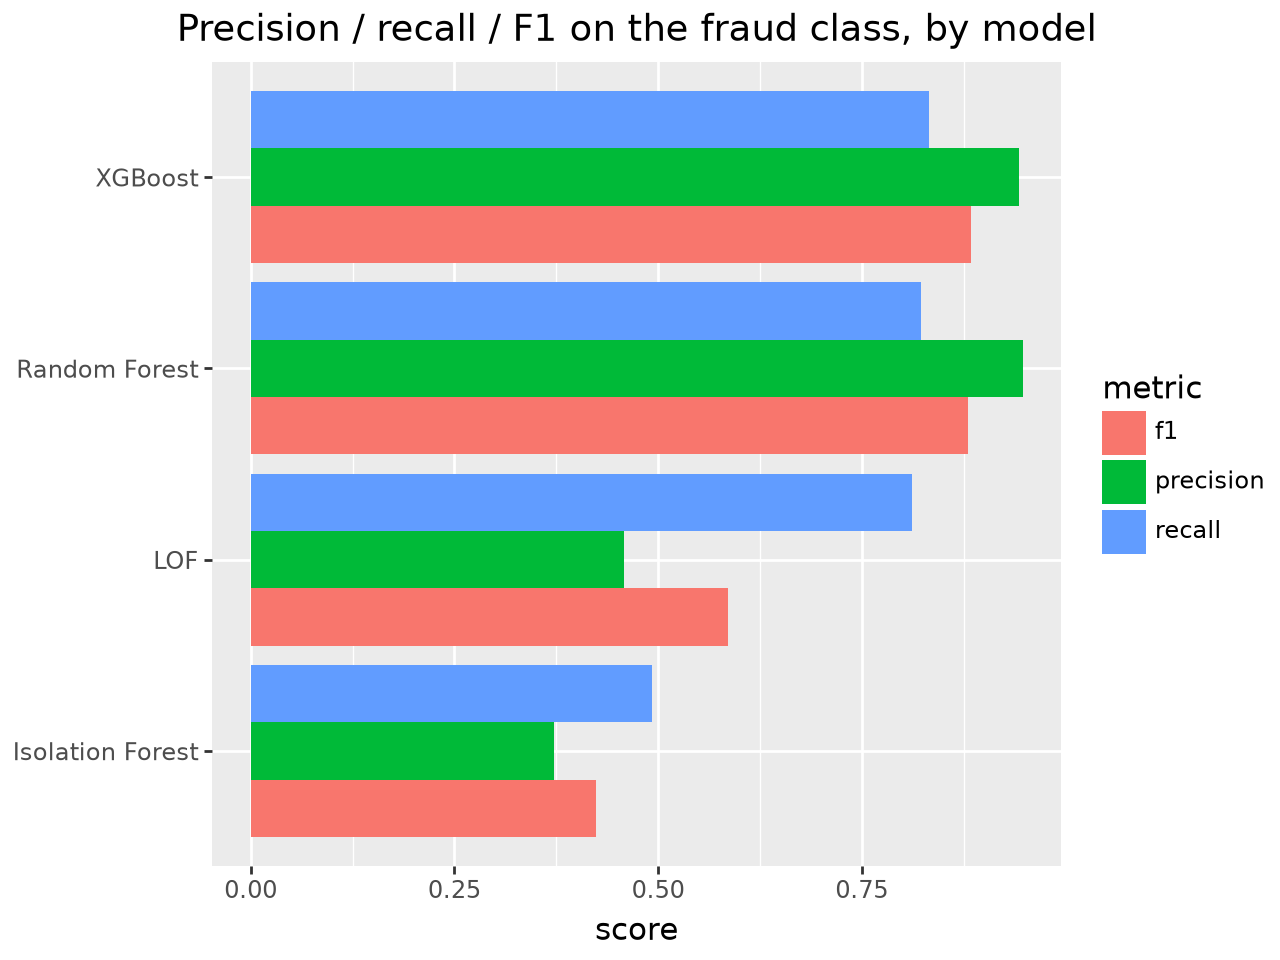

In [12]:
final_long = final_df.melt(id_vars='model', value_vars=['precision', 'recall', 'f1'],
                            var_name='metric', value_name='value')

(
    pln.ggplot(final_long, pln.aes(x='model', y='value', fill='metric'))
    + pln.geom_col(position='dodge')
    + pln.coord_flip()
    + pln.labs(x='', y='score', title='Precision / recall / F1 on the fraud class, by model',
               fill='metric')
)

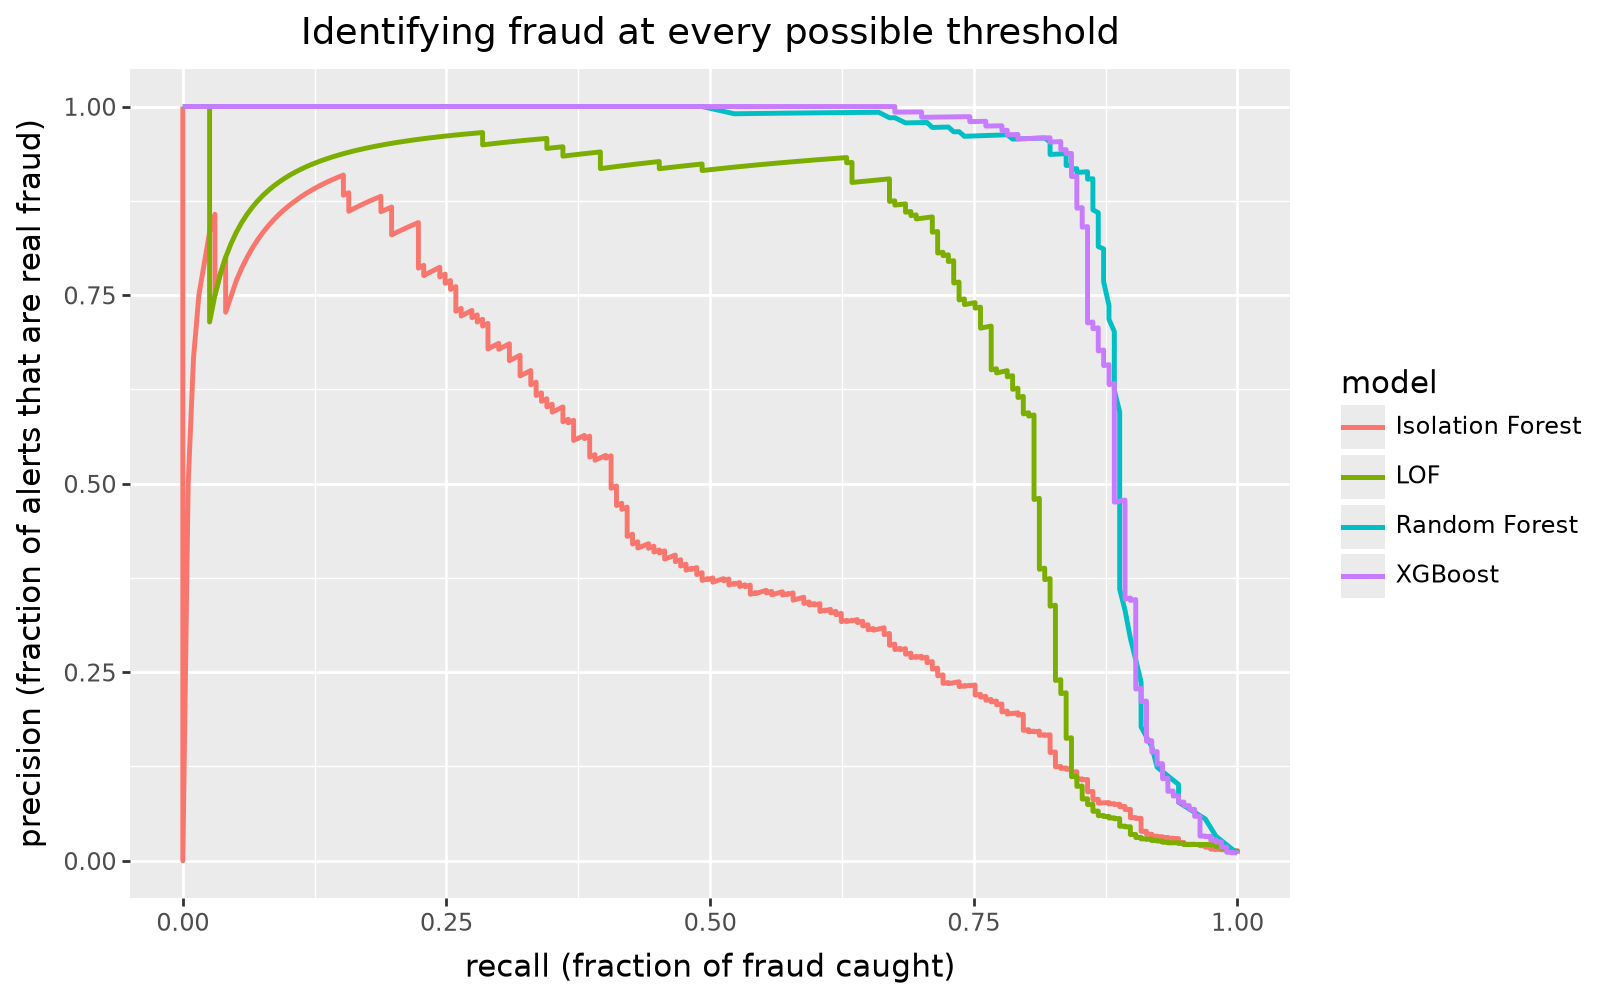

In [13]:
(
    pln.ggplot(curves_df, pln.aes(x='recall', y='precision', color='model'))
    + pln.geom_path(size=1)
    + pln.labs(title='Identifying fraud at every possible threshold',
               x='recall (fraction of fraud caught)', y='precision (fraction of alerts that are real fraud)')
    + pln.theme(figure_size=(8, 5))
)

A few things stand out (exact numbers will vary slightly by run, but the pattern is stable):

* **Random Forest and XGBoost** (both trained with class weighting, no undersampling to 50/50) come out clearly ahead on every metric - around 94% precision and 82-83% recall, for a PR-AUC near 0.89. That's the advantage of getting to see real, labeled fraud examples: the model can learn what fraud specifically looks like, not just "unusual."
* **LOF clearly outperforms Isolation Forest** here (PR-AUC of roughly 0.74 vs. 0.45, and about 81% recall vs. 49% at our chosen threshold). Fraud in this dataset seems to cluster into pockets that are *locally* sparse relative to their surroundings - exactly what LOF is built to notice - more than being globally rare in every direction, which is what Isolation Forest looks for.
* Even with **zero labeled fraud examples**, LOF still catches around 4 out of every 5 fraud cases, and Isolation Forest catches about half. That's the real selling point of unsupervised anomaly detection: it's the only option of the four when you don't have (enough) confirmed fraud labels yet, even though both are clearly the weaker choice, precision-wise, once you do.

## Summary: Bagging vs. Boosting vs. Isolation Forest vs. LOF

| | Random Forest (bagging) | XGBoost (boosting) | Isolation Forest | Local Outlier Factor |
|---|---|---|---|---|
| Learning type | supervised | supervised | unsupervised | unsupervised |
| How the ensemble is built | many trees, trained independently on bootstrap samples | many trees, trained sequentially, each fixing prior errors | many trees, built with purely random splits | not an ensemble - a single density comparison to k nearest neighbors |
| What "fraud" means to it | whatever pattern separates the two labeled classes | whatever pattern separates the two labeled classes | a point that's easy to isolate with few random splits (globally rare) | a point in a much sparser neighborhood than its neighbors (locally rare) |
| Needs feature scaling? | no | no | no | yes - it's distance-based |
| Needs labels? | yes | yes | no (only a rough contamination guess) | no (only a rough contamination guess) |
| Main strength | robust, hard to overfit, easy to parallelize | typically the most accurate when tuned well | scales well, can flag globally unusual points | catches locally unusual points a global method would miss |
| Main weakness | can miss subtle patterns a sequential method would catch | more sensitive to noisy/mislabeled data | can miss anomalies that are only *locally* unusual | slower (nearest-neighbor search), sensitive to scaling and choice of k |

In this tutorial we:

* Saw why **accuracy is the wrong metric** for a problem as imbalanced as fraud detection (99.83% accuracy for a model that never once predicts fraud), and used precision/recall/F1 instead.
* Contrasted **bagging** (independent trees, reduces variance) with **boosting** (sequential trees, reduces bias) using Random Forest and XGBoost.
* Learned that **balanced sampling matters** because it's often the only practical way to get a model to pay attention to a rare class at all - but that it also distorts the class prior the model learns, which can badly hurt precision on real, imbalanced data; keeping more data and reweighting the loss (`class_weight`/`scale_pos_weight`) is frequently a better trade-off than strict undersampling once training time allows it.
* Saw that **Isolation Forest and LOF need the opposite treatment**: since they rely on anomalies actually being rare, we fit them on normal-only data rather than a balanced sample.
* Compared all four models on a shared, realistically-imbalanced test set with confusion matrices, precision/recall/F1, and precision-recall curves - and found that labeled supervised models outperform label-free anomaly detectors here, but the anomaly detectors still catch a meaningful share of fraud with no labels at all, which is exactly the situation where they earn their keep.